In [ ]:
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

In [ ]:
train_transform = transforms.Compose([
    transforms.TrivialAugmentWide(num_magnitude_bins=5),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

In [ ]:
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, transform=train_transform, download=True)

test_data = torchvision.datasets.CIFAR10(root='./data', train=False, transform=test_transform, download=True)

In [ ]:
train_loader = torch.utils.data.DataLoader(dataset=train_data, batch_size=32, shuffle=True, num_workers=2)


test_loader = torch.utils.data.DataLoader(dataset=test_data, batch_size=32,shuffle= False, num_workers=2)





In [ ]:
image, label = train_data[0]


In [ ]:
image.size()

torch.Size([3, 32, 32])

In [ ]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
class ModelV0(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_3 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*4*4, out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    #print(x.shape)
    x = self.conv_block_2(x)
    #print(x.shape)
    x = self.conv_block_3(x)
    x = self.classifier(x)
    #print(x.shape)
    return x




In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

model_1 = ModelV0(3,32,10).to(device)


print(type(model_1.conv_block_1))
print(type(model_1.conv_block_2))





<class 'torch.nn.modules.container.Sequential'>
<class 'torch.nn.modules.container.Sequential'>


In [ ]:
image_batch, label_batch = next(iter(train_loader))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 32, 32]), torch.Size([32]))

In [ ]:
dummy_input = torch.randn(1,3,32,32)
output = model_1(dummy_input)
print(output)

tensor([[-0.0086, -0.0246,  0.0166,  0.0573, -0.0034,  0.0739,  0.0208,  0.0096,
         -0.0425,  0.0216]], grad_fn=<AddmmBackward0>)


In [ ]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model_1.parameters(), lr=0.01, momentum=0.9)

In [ ]:
import torch

def acc_fn(y_pred: torch.Tensor, y_true: torch.Tensor) -> float:
    """
    Calculates the classification accuracy.

    Args:
        y_pred: model outputs (logits) of shape [batch_size, num_classes]
        y_true: ground truth labels of shape [batch_size]

    Returns:
        Accuracy as a float (0.0 to 1.0)
    """
    # Get predicted class indices
    y_pred_labels = torch.argmax(y_pred, dim=1)

    # Compare with true labels and take mean
    correct = (y_pred_labels == y_true).sum().item()
    total = y_true.size(0)

    return correct / total



In [ ]:
epochs = 10

for epoch in range(epochs):

  model_1.train()
  print(f"training epoch {epoch}")

  train_loss, train_acc = 0,0

  for batch, (X,y) in enumerate(train_loader):
    X, y = X.to(device), y.to(device)

    optimizer.zero_grad()


    y_pred = model_1(X)

    loss = loss_fn(y_pred, y)

    acc = acc_fn(y_pred, y)

    train_loss += loss.item()

    train_acc += acc



    loss.backward()

    optimizer.step()


    y_pred_class = torch.argmax(y_pred, dim=1)
  train_loss /= len(train_loader)
  train_acc /= len(train_loader)


  test_loss, test_acc = 0,0

  model_1.eval()
  with torch.inference_mode():
    for X_test, y_test in test_loader:
      test_pred = model_1(X_test)

      test_loss += loss_fn(test_pred, y_test).item()

      acc = acc_fn(test_pred, y_test)

      test_acc += acc

    test_loss /= len(test_loader)
    test_acc /= len(test_loader)
  print(f"EPOCHS: {epoch} | train loss: {train_loss:4f} | train acc: {train_acc} |   test loss: {test_loss:4f}  |      test acc {test_acc}")










training epoch 0
EPOCHS: 0 | train loss: 2.137709 | train acc: 0.19385796545105566 |   test loss: 1.699968  |      test acc 0.3778953674121406
training epoch 1
EPOCHS: 1 | train loss: 1.750088 | train acc: 0.36628278950735765 |   test loss: 1.321307  |      test acc 0.5210662939297125
training epoch 2
EPOCHS: 2 | train loss: 1.522528 | train acc: 0.4527151311580294 |   test loss: 1.130690  |      test acc 0.5924520766773163
training epoch 3
EPOCHS: 3 | train loss: 1.403435 | train acc: 0.4958613243761996 |   test loss: 1.010774  |      test acc 0.6425718849840255
training epoch 4
EPOCHS: 4 | train loss: 1.324570 | train acc: 0.5285708573256558 |   test loss: 0.984067  |      test acc 0.6471645367412141
training epoch 5
EPOCHS: 5 | train loss: 1.279660 | train acc: 0.5438859564939219 |   test loss: 0.932275  |      test acc 0.6712260383386581
training epoch 6
EPOCHS: 6 | train loss: 1.249972 | train acc: 0.5569417786308382 |   test loss: 0.901890  |      test acc 0.6797124600638977
trai

In [ ]:
import matplotlib.pyplot as plt
import torch

# Make sure model is in eval mode
model_1.eval()

# Grab one batch from the test_loader
images, labels = next(iter(test_loader))

# Move to same device as model
images, labels = images.to(device), labels.to(device)

# Forward pass
with torch.inference_mode():
    outputs = model_1(images)
    preds = torch.argmax(outputs, dim=1)




In [ ]:
# Example for CIFAR-10
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

# Convert tensor to CPU for plotting
preds = preds.cpu()
labels = labels.cpu()
images = images.cpu()


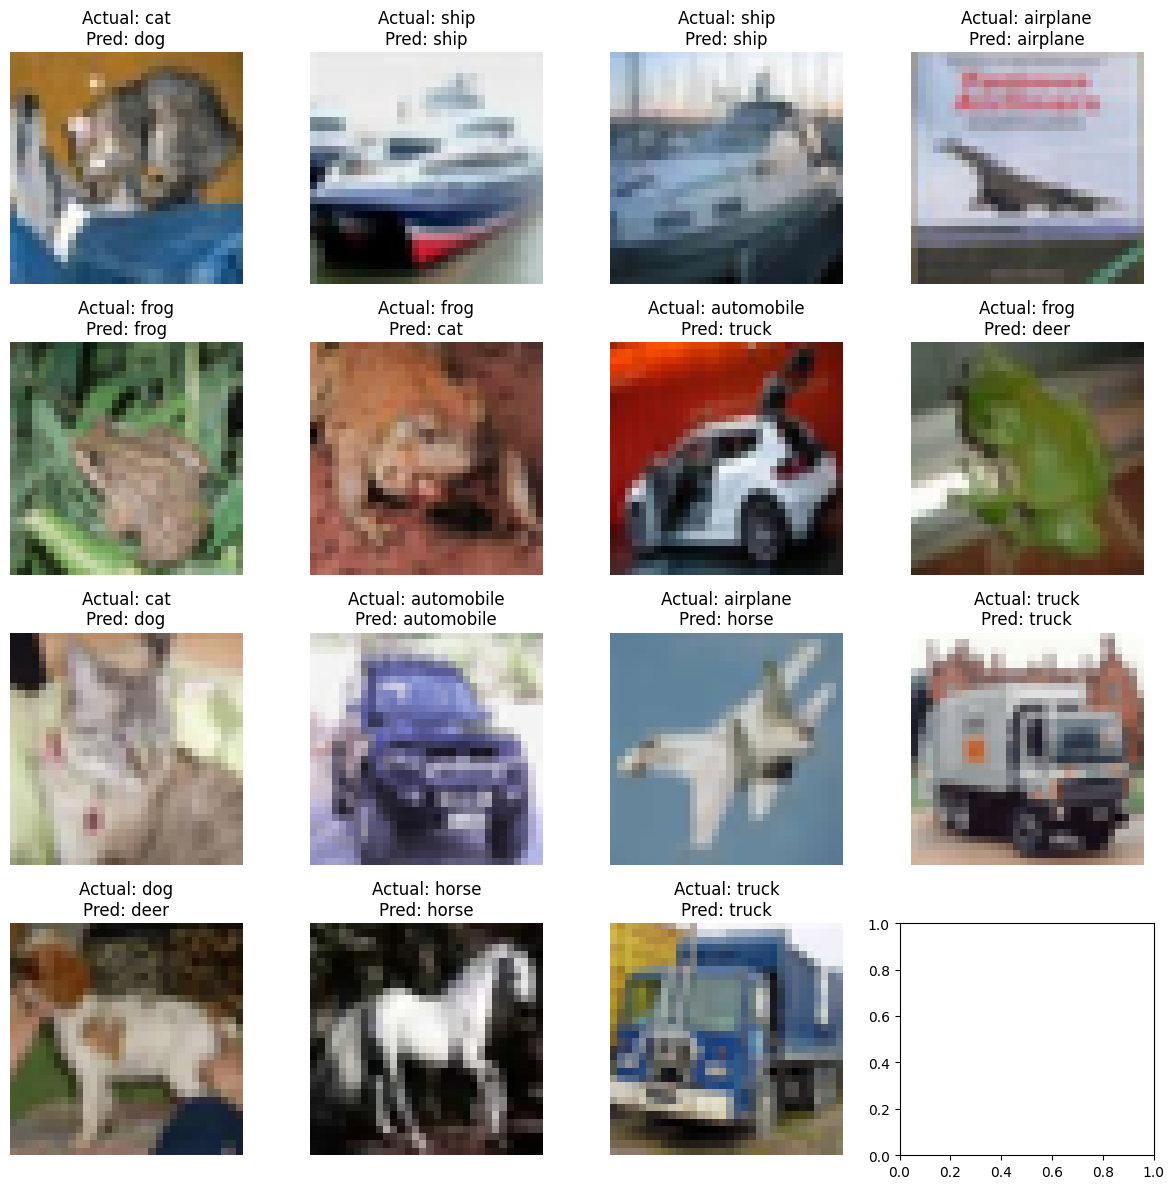

In [ ]:
num_images = 15
rows = (num_images + 4) // 4   # 4 per row

fig, axes = plt.subplots(rows, 4, figsize=(12, rows * 3))
axes = axes.flatten()

for i in range(num_images):
    img = images[i].permute(1,2,0) * 0.5 + 0.5
    axes[i].imshow(img)
    axes[i].set_title(f"Actual: {classes[labels[i]]}\nPred: {classes[preds[i]]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()
